# Section 1 · Q1 — Import & Examine the Data  (lipid_ext.csv)

Tasks (per PDF):
1) Import the dataset  
2) Print some of the data (shape, dtypes, head)  
3) Show descriptive statistics  
4) Do plots to visualize distributions  
5) Check missing values and categorical levels


Shape: (95, 20)

Dtypes:
 Name                object
Gender              object
Age                  int64
Weight               int64
Cholesterol          int64
Triglycerides        int64
HDL                  int64
LDL                float64
PercentIdeal       float64
Height             float64
Skinfold             int64
SystolicBP           int64
DiastolicBP          int64
Cholesterol3         int64
Exercise             int64
Coffee               int64
Smoking             object
Alcohol             object
HeartDisease        object
CholesterolLoss      int64
dtype: object

Head (first 10 rows):
              Name  Gender  Age  Weight  Cholesterol  Triglycerides  HDL  \
0         J. Suds    male   22     138          197            152   43   
1       T. Wilson  female   22     115          181             59   60   
2   D.S. Quintent    male   22     190          190            117   41   
3         R. Beal  female   22     115          131             54   58   
4        R. James    

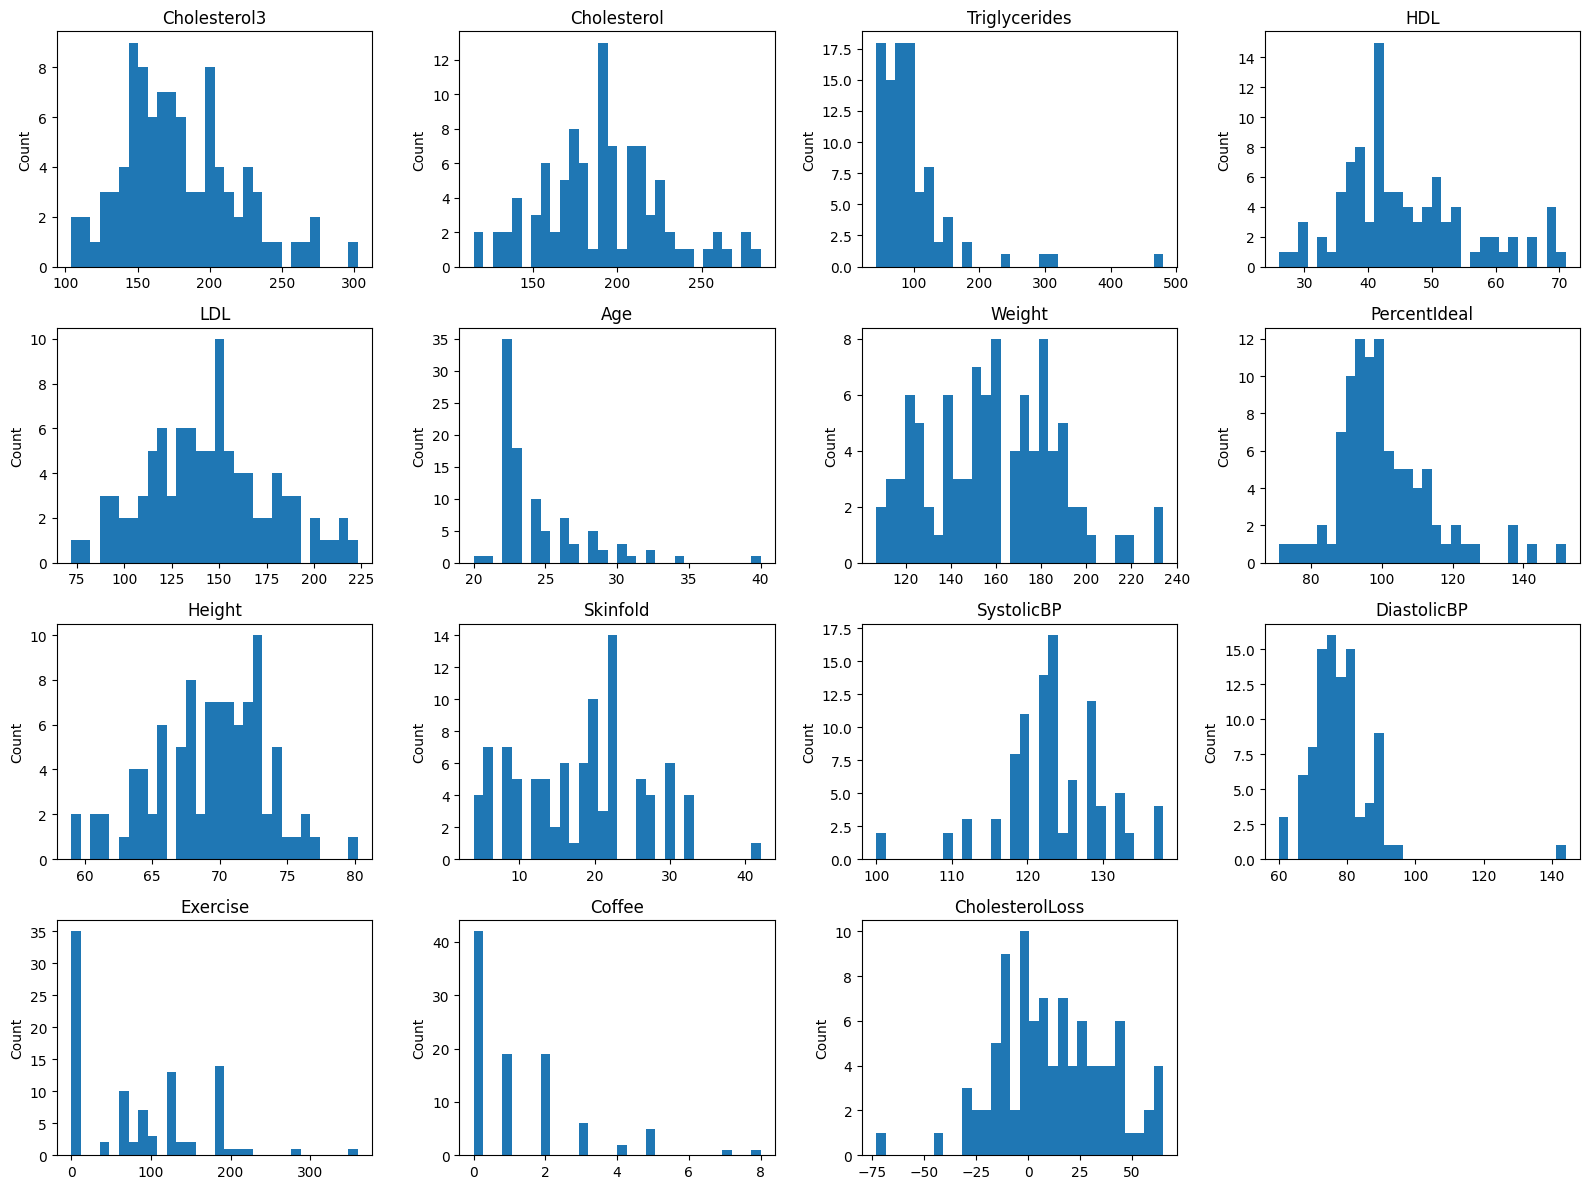

In [7]:
# Q1 — Import & Examine the Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) Import ----------------------------------------------------------
df = pd.read_csv("lipid_ext.csv")

# 2) Print some of the data ------------------------------------------
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nHead (first 10 rows):\n", df.head(10))

# 3) Descriptive statistics ------------------------------------------
# Numeric summary
desc_num = df.select_dtypes(include=[np.number]).describe().T
print("\nNumeric summary (describe):\n", desc_num)

# Categorical quick look
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
if cat_cols:
    print("\nCategorical columns:", cat_cols)
    for c in cat_cols:
        print(f"\nValue counts for {c}:\n", df[c].value_counts(dropna=False))

# 4) Missing values ---------------------------------------------------
na_counts = df.isna().sum().sort_values(ascending=False)
print("\nMissing values per column:\n", na_counts)

# 5) Plots: histograms for key numeric variables ---------------------
key_numeric = [
    "Cholesterol3", "Cholesterol", "Triglycerides", "HDL", "LDL",
    "Age", "Weight", "PercentIdeal", "Height", "Skinfold",
    "SystolicBP", "DiastolicBP", "Exercise", "Coffee", "CholesterolLoss"
]
existing = [c for c in key_numeric if c in df.columns]

n = len(existing)
cols = 4
rows = int(np.ceil(n / cols))
plt.figure(figsize=(4 * cols, 3 * rows))

for i, col in enumerate(existing, 1):
    ax = plt.subplot(rows, cols, i)
    series = pd.to_numeric(df[col], errors="coerce").dropna()
    ax.hist(series, bins=30)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


# Section 1 · Q2 — Find a Reasonable Transformation of Triglycerides  

Tasks (per PDF):  
1) Inspect the distribution of *Triglycerides* to check normality.  
2) Apply several transformations (log, square root, Box–Cox).  
3) Use plots and Shapiro–Wilk tests to decide which transformation best normalizes the data.  
4) Store the chosen transformed variable for later questions.


Box–Cox lambda: -0.6588575996474043


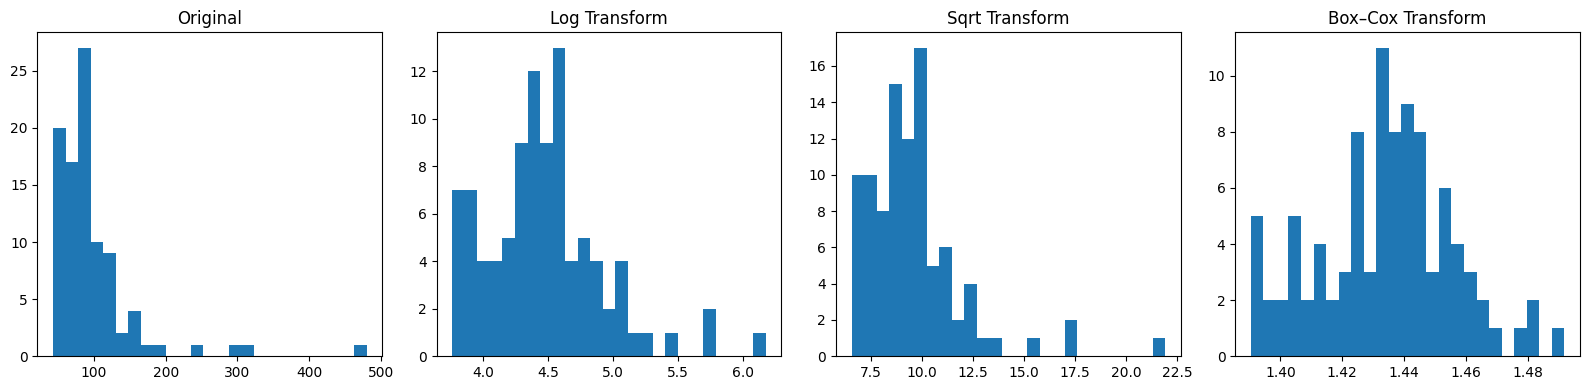

Triglycerides             W=0.6524, p=0.0000
Triglycerides_log         W=0.9358, p=0.0002
Triglycerides_sqrt        W=0.8205, p=0.0000
Triglycerides_boxcox      W=0.9825, p=0.2345


In [8]:
# Q2 — Find a Reasonable Transformation of Triglycerides
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Extract triglycerides column
x = df["Triglycerides"]

# Apply transformations
df["Triglycerides_log"] = np.log(x)
df["Triglycerides_sqrt"] = np.sqrt(x)
df["Triglycerides_boxcox"], lambda_bc = stats.boxcox(x)
print("Box–Cox lambda:", lambda_bc)

# Plot histograms
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].hist(x, bins=25); axes[0].set_title("Original")
axes[1].hist(df["Triglycerides_log"], bins=25); axes[1].set_title("Log Transform")
axes[2].hist(df["Triglycerides_sqrt"], bins=25); axes[2].set_title("Sqrt Transform")
axes[3].hist(df["Triglycerides_boxcox"], bins=25); axes[3].set_title("Box–Cox Transform")
plt.tight_layout(); plt.show()

# Shapiro–Wilk tests for normality
for col in ["Triglycerides", "Triglycerides_log", "Triglycerides_sqrt", "Triglycerides_boxcox"]:
    stat, p = stats.shapiro(df[col])
    print(f"{col:25s} W={stat:.4f}, p={p:.4f}")


# Section 1 · Q3 — Create Binary Variables (Age, Coffee, Exercise)

Tasks (per PDF):  
1) Create binary variables as follows:  
   • **Age_binary** = 1 if Age > 25, else 0  
   • **Coffee_any** = 1 if Coffee > 0, else 0  
   • **Exercise_ge30** = 1 if Exercise ≥ 30 minutes, else 0  
2) Display the new columns to confirm correct creation.


In [9]:
# Q3 — Create Binary Variables
import numpy as np

# Create binary columns based on conditions
df["Age_binary"] = (df["Age"] > 25).astype(int)
df["Coffee_any"] = (df["Coffee"] > 0).astype(int)
df["Exercise_ge30"] = (df["Exercise"] >= 30).astype(int)

# Verify results
print(df[["Age", "Age_binary", "Coffee", "Coffee_any", "Exercise", "Exercise_ge30"]].head(10))


   Age  Age_binary  Coffee  Coffee_any  Exercise  Exercise_ge30
0   22           0       1           1       180              1
1   22           0       2           1         0              0
2   22           0       0           0        90              1
3   22           0       5           1       120              1
4   25           0       2           1        40              1
5   22           0       0           0         0              0
6   23           0       2           1         0              0
7   24           0       0           0        90              1
8   23           0       1           1        60              1
9   22           0       0           0        40              1


# Section 1 · Q4 — Fit OLS on Cholesterol3 (Exclude CholesterolLoss) — Formula Version

- Dependent: **Cholesterol3**  
- Predictors: Triglycerides_boxcox, HDL, LDL, PercentIdeal, Height, Skinfold, SystolicBP, DiastolicBP, Weight, Age_binary, Coffee_any, Exercise_ge30  
- Categorical (dummy via formula): **Gender**, **Smoking**, **Alcohol**, **HeartDisease**  
- **Exclude CholesterolLoss** as required.


In [12]:
# Q4 — OLS using formula (handles categorical dummies automatically)

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# Ensure numeric columns used as numeric (coerce in place; no changes to categories)
num_to_check = [
    "Cholesterol3","Triglycerides_boxcox","HDL","LDL","PercentIdeal","Height",
    "Skinfold","SystolicBP","DiastolicBP","Weight","Age_binary","Coffee_any","Exercise_ge30"
]
for c in num_to_check:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop rows with missing values in any model term (rare after Q1–Q3)
model_vars = num_to_check + ["Gender","Smoking","Alcohol","HeartDisease"]
df_q4 = df.dropna(subset=model_vars).copy()

# Build and fit the model (exclude CholesterolLoss)
formula = (
    "Cholesterol3 ~ Triglycerides_boxcox + HDL + LDL + PercentIdeal + Height + "
    "Skinfold + SystolicBP + DiastolicBP + Weight + Age_binary + Coffee_any + Exercise_ge30 + "
    "C(Gender) + C(Smoking) + C(Alcohol) + C(HeartDisease)"
)
ols_full = smf.ols(formula=formula, data=df_q4).fit()
print(ols_full.summary())


                            OLS Regression Results                            
Dep. Variable:           Cholesterol3   R-squared:                       0.673
Model:                            OLS   Adj. R-squared:                  0.584
Method:                 Least Squares   F-statistic:                     7.601
Date:                Tue, 04 Nov 2025   Prob (F-statistic):           4.00e-11
Time:                        13:45:22   Log-Likelihood:                -431.93
No. Observations:                  95   AIC:                             905.9
Df Residuals:                      74   BIC:                             959.5
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

# Section 1 · Q5 — Why NOT include CholesterolLoss?  What happens to R² if included?

Tasks (per PDF):  
1) Explain conceptually why **CholesterolLoss** should not be included.  
   - It is computed from Cholesterol values over time (a post-treatment measure).  
   - Including it would create **endogeneity** and **target leakage**.  
2) Demonstrate the effect on R² by re-fitting the model **with CholesterolLoss** included.


In [13]:
# Q5 — Demonstrate effect of including CholesterolLoss

import statsmodels.formula.api as smf

# Fit the same model but add CholesterolLoss
formula_with_loss = (
    "Cholesterol3 ~ Triglycerides_boxcox + HDL + LDL + PercentIdeal + Height + "
    "Skinfold + SystolicBP + DiastolicBP + Weight + Age_binary + Coffee_any + Exercise_ge30 + "
    "C(Gender) + C(Smoking) + C(Alcohol) + C(HeartDisease) + CholesterolLoss"
)

ols_with_loss = smf.ols(formula=formula_with_loss, data=df_q4).fit()

# Compare R² values
print("R² without CholesterolLoss :", round(ols_full.rsquared, 3))
print("R² with CholesterolLoss    :", round(ols_with_loss.rsquared, 3))

# Display short summary lines
print("\nCoefficient on CholesterolLoss:", round(ols_with_loss.params['CholesterolLoss'], 4))
print("p-value for CholesterolLoss:", round(ols_with_loss.pvalues['CholesterolLoss'], 4))


R² without CholesterolLoss : 0.673
R² with CholesterolLoss    : 1.0

Coefficient on CholesterolLoss: -1.004
p-value for CholesterolLoss: 0.0


# Section 1 · Q6 — Check Model Assumptions (Fixed for Matplotlib ≥3.9)

Includes:
1) Cook’s Distance  
2) Residual Normality (Q–Q plot)  
3) Residual vs Fitted (Linearity & Constant Variance)  
4) Variance Inflation Factors (VIF)


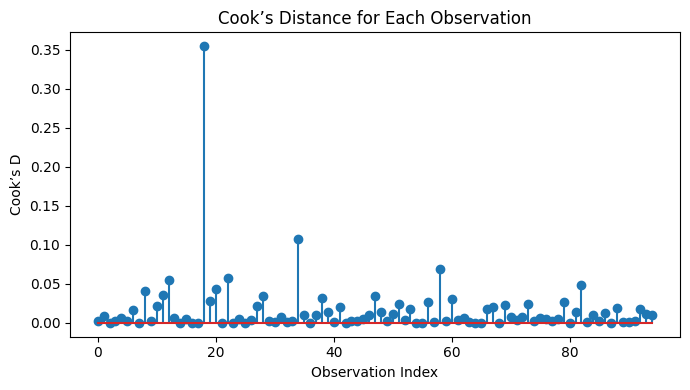

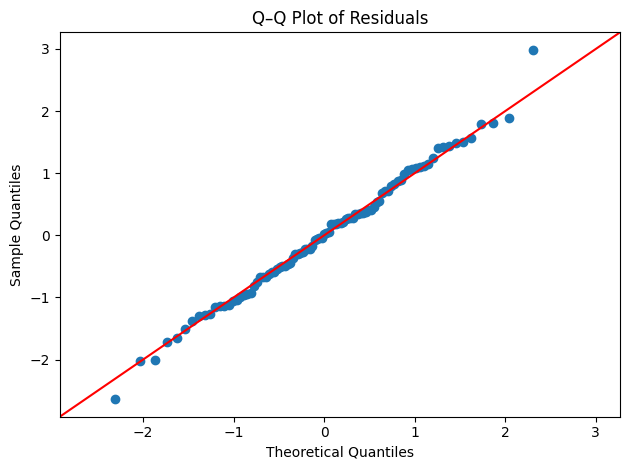

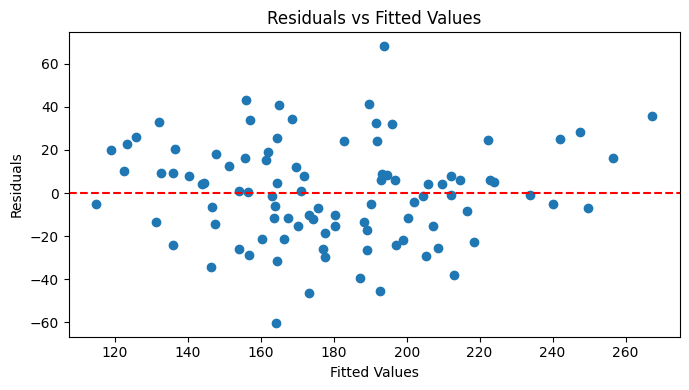


Variance Inflation Factors:
                   Variable          VIF
12                   Height  4623.221603
8      Triglycerides_boxcox  4485.861394
16                   Weight   750.987925
11             PercentIdeal   578.546841
14               SystolicBP   441.096769
15              DiastolicBP    84.894585
9                       HDL    30.910435
10                      LDL    28.770956
0         C(Gender)[T.male]    14.622425
6   C(HeartDisease)[T.none]    10.993416
13                 Skinfold     9.452807
19            Exercise_ge30     3.924965
7   C(HeartDisease)[T.over]     3.401863
4        C(Alcohol)[T.zero]     3.003182
18               Coffee_any     2.857817
2         C(Alcohol)[T.< 2]     2.731712
5    C(HeartDisease)[T.<60]     2.203976
17               Age_binary     1.790005
1         C(Smoking)[T.yes]     1.774327
3         C(Alcohol)[T.> 6]     1.327742


In [15]:
# Q6 — Diagnostics (fixed stem plot syntax)

import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.outliers_influence import OLSInfluence, variance_inflation_factor
import pandas as pd

# Residuals and fitted values
resid = ols_full.resid
fitted = ols_full.fittedvalues

# 1) Cook's Distance -------------------------------------------------
influence = OLSInfluence(ols_full)
cooks_d = influence.cooks_distance[0]

plt.figure(figsize=(7,4))
plt.stem(np.arange(len(cooks_d)), cooks_d)
plt.title("Cook’s Distance for Each Observation")
plt.xlabel("Observation Index")
plt.ylabel("Cook’s D")
plt.tight_layout()
plt.show()

# 2) Normality: Q–Q Plot --------------------------------------------
qqplot(resid, line="45", fit=True)
plt.title("Q–Q Plot of Residuals")
plt.tight_layout()
plt.show()

# 3) Linearity & Homoscedasticity -----------------------------------
plt.figure(figsize=(7,4))
plt.scatter(fitted, resid)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.tight_layout()
plt.show()

# 4) Multicollinearity (VIF) ----------------------------------------
# Get model matrix and variable names
model_exog = ols_full.model.exog
model_names = ols_full.model.exog_names

X_vif = pd.DataFrame(model_exog, columns=model_names).drop(columns=["Intercept"], errors="ignore")

vif_df = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

print("\nVariance Inflation Factors:")
print(vif_df)


# Section 1 · Q7 — Variable Selection (using AIC stepwise)

Tasks (per PDF):  
1) Perform variable selection to find a more parsimonious model.  
2) Use AIC as the criterion for adding/removing variables.  
3) Fit the reduced model and summarize results.  
4) Compare its fit to the full model from Q4.


In [16]:
# Q7 — Stepwise Variable Selection by AIC

import statsmodels.api as sm
import pandas as pd

# Get the design matrix from the ols_full formula model
X_full = pd.DataFrame(ols_full.model.exog, columns=ols_full.model.exog_names)
y_full = ols_full.model.endog

# Drop the Intercept for selection logic; add back later
X_candidates = X_full.drop(columns=["Intercept"], errors="ignore")

def stepwise_aic(X, y):
    included = []
    best_changed = True
    while best_changed:
        best_changed = False
        # forward step
        excluded = list(set(X.columns) - set(included))
        new_aic = pd.Series(index=excluded, dtype=float)
        for col in excluded:
            model = sm.OLS(y, sm.add_constant(X[included + [col]])).fit()
            new_aic[col] = model.aic
        if not new_aic.empty:
            best_new = new_aic.idxmin()
            best_aic = new_aic.min()
            if included:
                current_aic = sm.OLS(y, sm.add_constant(X[included])).fit().aic
            else:
                current_aic = sm.OLS(y, sm.add_constant(pd.DataFrame(index=range(len(y))))).fit().aic
            if best_aic + 1e-6 < current_aic:
                included.append(best_new)
                best_changed = True
        # backward step
        if included:
            aics = pd.Series(index=included, dtype=float)
            for col in included:
                keep = [c for c in included if c != col]
                model = sm.OLS(y, sm.add_constant(X[keep])).fit()
                aics[col] = model.aic
            worst = aics.idxmin()
            lowest_aic = aics.min()
            full_aic = sm.OLS(y, sm.add_constant(X[included])).fit().aic
            if lowest_aic + 1e-6 < full_aic:
                included.remove(worst)
                best_changed = True
    return included

selected_vars = stepwise_aic(X_candidates, y_full)
print("Selected variables by AIC:\n", selected_vars)

# Fit reduced model with selected predictors
X_reduced = sm.add_constant(X_candidates[selected_vars])
ols_reduced = sm.OLS(y_full, X_reduced).fit()
print("\nReduced Model Summary:\n")
print(ols_reduced.summary())

# Compare AIC and R² with full model
print("\nFull model AIC:", round(ols_full.aic, 2), 
      " R²:", round(ols_full.rsquared, 3))
print("Reduced model AIC:", round(ols_reduced.aic, 2), 
      " R²:", round(ols_reduced.rsquared, 3))


Selected variables by AIC:
 ['LDL', 'HDL', 'C(Alcohol)[T.> 6]', 'Height', 'C(Alcohol)[T.zero]']

Reduced Model Summary:

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.635
Model:                            OLS   Adj. R-squared:                  0.615
Method:                 Least Squares   F-statistic:                     30.97
Date:                Tue, 04 Nov 2025   Prob (F-statistic):           3.99e-18
Time:                        13:47:45   Log-Likelihood:                -437.09
No. Observations:                  95   AIC:                             886.2
Df Residuals:                      89   BIC:                             901.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--

# Section 1 · Q8 — Ridge Regression (no standardization, fixed for sklearn ≥1.5)

Same steps:
1) Use the full OLS predictors  
2) Search λ (alpha) values  
3) Report best λ and in-sample R²  
4) Plot residuals vs fitted


Best alpha (lambda): 6866.488450042998
Ridge R² (in-sample): 0.591


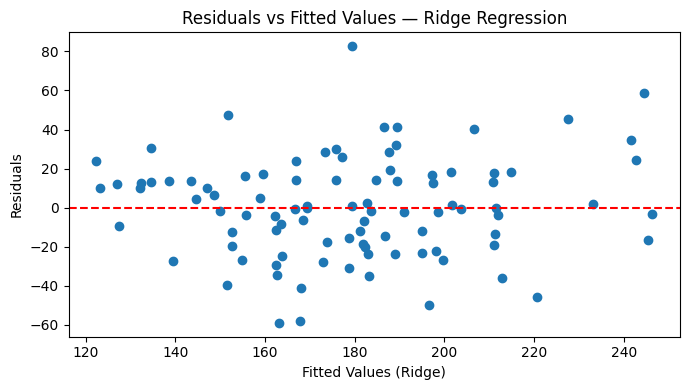

In [18]:
# Q8 — Ridge Regression (fixed)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV, Ridge

# Design matrix and target from full OLS model
X_full_np = np.asarray(ols_full.model.exog)
y_full_np = np.asarray(ols_full.model.endog)

# Candidate alphas (λ)
alphas = np.logspace(-4, 4, 50)

# Cross-validated Ridge (modern sklearn)
ridge_cv = RidgeCV(alphas=alphas, store_cv_results=False, fit_intercept=False)
ridge_cv.fit(X_full_np, y_full_np)

best_alpha = ridge_cv.alpha_
print("Best alpha (lambda):", best_alpha)

# Fit final Ridge model
ridge = Ridge(alpha=best_alpha, fit_intercept=False)
ridge.fit(X_full_np, y_full_np)

# Predicted and residuals
y_pred = ridge.predict(X_full_np)
resid = y_full_np - y_pred

# R² (in-sample)
r2 = ridge.score(X_full_np, y_full_np)
print("Ridge R² (in-sample):", round(r2, 3))

# Plot residuals vs fitted
plt.figure(figsize=(7, 4))
plt.scatter(y_pred, resid)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted Values (Ridge)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values — Ridge Regression")
plt.tight_layout()
plt.show()


# Section 1 · Q9 — Compare Residuals and Coefficients

Tasks:

1. Compare **Mean Squared Errors (MSE)** of the three models:  
   - Full OLS (from Q4)  
   - Reduced OLS (from Q7)  
   - Ridge (from Q8)  
2. Compare regression coefficients across models.  
3. Discuss differences and trade-offs in model fit and coefficient shrinkage.


In [20]:
# Q9 — Compare Residuals and Coefficients

import numpy as np
import pandas as pd

# --- 1) Mean Squared Error (MSE) comparison ----------------------------
mse_full = np.mean(ols_full.resid.values ** 2)
mse_reduced = np.mean(ols_reduced.resid.values ** 2)
mse_ridge = np.mean((y_full_np - ridge.predict(X_full_np)) ** 2)

print(f"MSE (Full OLS):     {mse_full:.4f}")
print(f"MSE (Reduced OLS):  {mse_reduced:.4f}")
print(f"MSE (Ridge):        {mse_ridge:.4f}")

# --- 2) Coefficient comparison ----------------------------------------
coef_full = pd.Series(ols_full.params, name="Full_OLS")
coef_reduced = pd.Series(ols_reduced.params, name="Reduced_OLS").rename(index={"const": "Intercept"})

# Ridge uses the same design matrix as ols_full (fit_intercept=False)
ridge_series = pd.Series(ridge.coef_, index=ols_full.model.exog_names, name="Ridge")

# Combine all three models' coefficients
coef_compare = pd.concat([coef_full, coef_reduced, ridge_series], axis=1)

print("\nCoefficient comparison (first 20 rows):\n")
print(coef_compare.head(20))


MSE (Full OLS):     520.8495
MSE (Reduced OLS):  580.6270
MSE (Ridge):        651.2027

Coefficient comparison (first 20 rows):

                           Full_OLS  Reduced_OLS     Ridge
Intercept                601.460192   -72.504194  0.002172
C(Gender)[T.male]        -12.791990          NaN -0.013278
C(Smoking)[T.yes]          2.875314          NaN  0.004465
C(Alcohol)[T.< 2]          7.197296          NaN  0.005088
C(Alcohol)[T.> 6]        -45.258469   -42.975417 -0.010835
C(Alcohol)[T.zero]         8.872183     8.350227  0.026096
C(HeartDisease)[T.<60]     2.366724          NaN  0.007872
C(HeartDisease)[T.none]   -4.423322          NaN -0.009544
C(HeartDisease)[T.over]  -15.241084          NaN -0.007285
Triglycerides_boxcox    -199.167874          NaN  0.002326
HDL                        0.896958     1.026569  0.540253
LDL                        1.004862     0.891053  0.851898
PercentIdeal              -1.208267          NaN -0.099481
Height                    -3.782743     1.077

# Section 2 · Q1 — Check the Poisson Assumption

Tasks (from the PDF):

1. Import the **Prussian-Horse-Kick-Data.csv** dataset.  
2. Plot a histogram of deaths per corps per year.  
3. Calculate the sample **mean** and **variance**.  
   - For a true Poisson process, these should be approximately equal.  
4. Create a **Poissonness plot**:  
   - Plot log(frequency) + log(k!) against k (number of deaths).  
   - A roughly linear relationship supports the Poisson assumption.


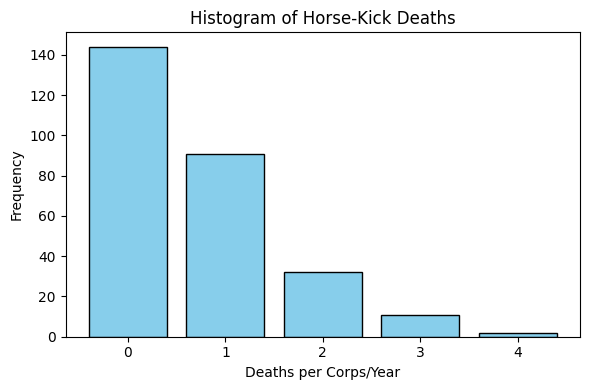

Mean deaths: 0.700
Variance of deaths: 0.763


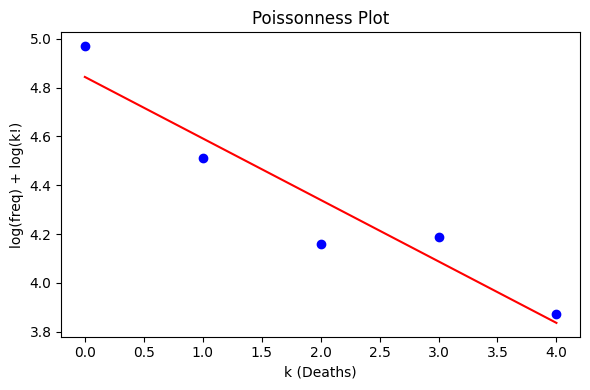

Slope and intercept of Poissonness line: [-0.25184293  4.8437682 ]


In [22]:
# Q1 — Check the Poisson Assumption (fixed)

import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

# 1) Load data
ph = pd.read_csv("Prussian-Horse-Kick-Data.csv")

# 2) Histogram of deaths
plt.figure(figsize=(6, 4))
plt.hist(
    ph["deaths"],
    bins=range(int(ph["deaths"].min()), int(ph["deaths"].max()) + 2),
    align="left",
    rwidth=0.8,
    color="skyblue",
    edgecolor="black"
)
plt.xlabel("Deaths per Corps/Year")
plt.ylabel("Frequency")
plt.title("Histogram of Horse-Kick Deaths")
plt.tight_layout()
plt.show()

# 3) Mean and variance
mean_deaths = ph["deaths"].mean()
var_deaths = ph["deaths"].var(ddof=1)
print(f"Mean deaths: {mean_deaths:.3f}")
print(f"Variance of deaths: {var_deaths:.3f}")

# 4) Poissonness plot
freq = ph["deaths"].value_counts().sort_index()
dfp = pd.DataFrame({"k": freq.index, "freq": freq.values})
dfp["k_factorial"] = dfp["k"].apply(lambda x: math.factorial(int(x)))
dfp["adj_log"] = np.log(dfp["freq"]) + np.log(dfp["k_factorial"])

plt.figure(figsize=(6, 4))
plt.scatter(dfp["k"], dfp["adj_log"], color="blue")
coef = np.polyfit(dfp["k"], dfp["adj_log"], 1)
xx = np.linspace(dfp["k"].min(), dfp["k"].max(), 100)
yy = np.polyval(coef, xx)
plt.plot(xx, yy, color="red")
plt.xlabel("k (Deaths)")
plt.ylabel("log(freq) + log(k!)")
plt.title("Poissonness Plot")
plt.tight_layout()
plt.show()

print("Slope and intercept of Poissonness line:", coef)


# Section 2 · Q2 — Poisson Regression with “fisher” Indicator

Tasks (from the PDF):

1. Convert the variable **fisher** into a binary indicator (1 if "fisher", 0 otherwise).  
2. Fit a **Poisson regression model**:  
   - Dependent variable: `deaths`  
   - Predictor: `fisher`  
3. Display the regression summary.  
4. Interpret whether Fisher’s exclusion was statistically justified.


In [23]:
# Q2 — Poisson Regression with "fisher" Indicator

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Load data
ph = pd.read_csv("Prussian-Horse-Kick-Data.csv")

# 1) Convert "fisher" column to binary indicator
# Assume column name is 'fisher'; if not, adjust accordingly
ph["fisher01"] = ph["fisher"].astype(str).str.strip().str.lower().isin(["yes", "y", "1", "true"]).astype(int)

# 2) Fit Poisson regression model
poisson_model = smf.glm("deaths ~ fisher01", data=ph, family=sm.families.Poisson()).fit()

# 3) Display model summary
print(poisson_model.summary())

# 4) Interpretation: compute incidence rate ratio (IRR)
coef = poisson_model.params["fisher01"]
pval = poisson_model.pvalues["fisher01"]
irr = np.exp(coef)

print("\nIncidence Rate Ratio (fisher=1 vs 0):", round(irr, 3))
print("p-value for fisher01:", round(pval, 4))

if pval < 0.05:
    print("Interpretation: The fisher indicator is significant — Fisher’s exclusion appears justified.")
else:
    print("Interpretation: The fisher indicator is not significant — Fisher’s exclusion is not statistically supported.")


                 Generalized Linear Model Regression Results                  
Dep. Variable:                 deaths   No. Observations:                  280
Model:                            GLM   Df Residuals:                      278
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -310.32
Date:                Tue, 04 Nov 2025   Deviance:                       315.56
Time:                        13:54:40   Pearson chi2:                     292.
No. Iterations:                     5   Pseudo R-squ. (CS):            0.02702
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0780      0.116     -0.671      0.5